Path: A -> B -> D


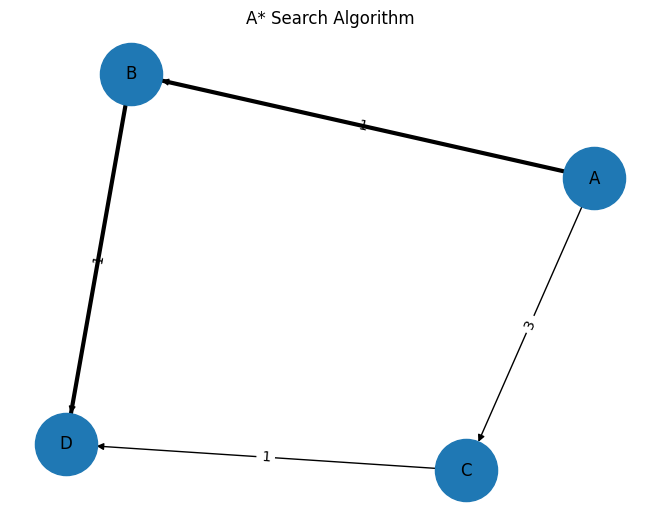

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

# Graph
graph = {
    'A': {'B':1, 'C':3},
    'B': {'D':1},
    'C': {'D':1},
    'D': {}
}

# Heuristic values
h = {'A':3, 'B':1, 'C':1, 'D':0}

# A* Algorithm
def a_star(start, goal):
    open_list = [start]
    g = {start:0}
    parent = {start:None}

    while open_list:
        n = min(open_list, key=lambda x: g[x] + h[x])

        if n == goal:
            path = []
            while n:
                path.append(n)
                n = parent[n]
            return path[::-1]

        open_list.remove(n)

        for neighbor in graph[n]:
            cost = g[n] + graph[n][neighbor]

            if neighbor not in g or cost < g[neighbor]:
                g[neighbor] = cost
                parent[neighbor] = n
                open_list.append(neighbor)

# Run
result = a_star('A', 'D')

print("Path:", " -> ".join(result))

# Draw Graph
G = nx.DiGraph()

for u in graph:
    for v, w in graph[u].items():
        G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

# Edge labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Highlight path
path_edges = [(result[i], result[i+1]) for i in range(len(result)-1)]
nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=3)

plt.title("A* Search Algorithm")
plt.show()